<a href="https://colab.research.google.com/github/dawon-04/lck-viewership-dashboard-uewndcbm/blob/main/Gen_G_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# [셀 0] 드라이브 마운트
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# [셀 1] 파일 불러오기
worlds = pd.read_excel(
    "/content/drive/MyDrive/Gen.G/cleaned_data_2025_Worlds.xlsx",
    sheet_name="25WorldsViewership_CleanedData"
)

lck = pd.read_excel(
    "/content/drive/MyDrive/Gen.G/공유_[LCK] VIEWERSHIP_MASTER_260304.xlsx",
    sheet_name="2015-2026_LCK",
    header=1
)

glob = pd.read_excel(
    "/content/drive/MyDrive/Gen.G/공유_[LCK] VIEWERSHIP_MASTER_260304.xlsx",
    sheet_name="2017-2025_GLOBAL",
    header=1
)

# 2026 RTM 파일의 'Total' 시트를 header=1로 불러오기
lck_rtm = pd.read_excel(
    "/content/drive/MyDrive/Gen.G/2026 LCK Viewership_RTM.xlsx",
    sheet_name="Total",
    header=1,
)

print("worlds:", worlds.shape)
print("lck:", lck.shape)
print("glob:", glob.shape)
print("lck_rtm (Total 시트):", lck_rtm.shape)

worlds: (24632, 18)
lck: (22128, 30)
glob: (2342, 29)
lck_rtm (Total 시트): (3097, 27)


/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [3]:
# [셀 2] Worlds 처리 — Series 빈 행 제외, 지표명 통일
worlds = worlds[worlds["Series"].notna()].copy()

worlds = worlds.rename(columns={
    "AMA": "Avg_Viewers",
    "Peak Viewers": "Peak_Viewers_sub"
})
worlds["Source"] = "Worlds_2025"

print("worlds 처리 완료:", worlds.shape)

worlds 처리 완료: (24632, 19)


In [4]:
# ============================================
# 2026 CUP Huya TV 날짜 오류 수정 (연도+스플릿 구분 버전 - 더 안전함)
# ============================================
lck['_grp'] = lck['Year'].astype(str) + "_" + lck['Split'].astype(str) + "_" + lck['Match'].astype(str)

match_correct_day = lck[lck['Platform']!='Huya TV'].groupby('_grp')['Day'].agg(
    lambda x: x.mode()[0] if len(x.mode())>0 else None
)

huya_mask = (lck['Year']==2026) & (lck['Platform']=='Huya TV')
lck.loc[huya_mask, 'Day'] = lck.loc[huya_mask, '_grp'].map(match_correct_day).fillna(lck.loc[huya_mask, 'Day'])

lck = lck.drop(columns=['_grp'])
print("수정 완료 (연도/스플릿 구분 버전)")

수정 완료 (연도/스플릿 구분 버전)


In [5]:
# [셀 3] LCK 시트 기본 정리
lck = lck.drop(columns=[c for c in lck.columns if "Unnamed" in str(c)])
lck = lck[lck["Year"].isin([2024, 2025, 2026])].copy()

lck["ACU"] = pd.to_numeric(lck["ACU"], errors="coerce")
lck["PCU"] = pd.to_numeric(lck["PCU"], errors="coerce")

print("lck 정리 완료:", lck.shape)

lck 정리 완료: (8908, 29)


In [6]:
# [셀 4] LCK 2024년 하루 1경기였던 16일(312행) 매치업 채우기
team_map_2024 = {
    "Gen.G": "GEN",
    "Hanwha Life Esports": "HLE",
    "T1": "T1",
    "kt Rolster": "KT",
    "KT Rolster": "KT",
    "Dplus KIA": "DK",
    "Dplus Kia": "DK",
    "Kwangdong Freecs": "DNS",
    "DN SOOPers": "DNS",
    "FearX": "BFX",
    "BNK FearX": "BFX",
    "BNK FEARX": "BFX",
    "Nongshim RedForce": "NS",
    "NongShim RedForce": "NS",
    "OKSavingsBank BRION": "BRO",
    "HANJIN BRION": "BRO",
    "DRX": "KRX",  # DRX -> KRX로 통일
    "KIWOOM DRX": "KRX",
}

single_match_days = {
    ("Spring", 3, 30): ("Hanwha Life Esports", "Kwangdong Freecs"),
    ("Spring", 3, 31): ("KT Rolster", "Dplus KIA"),
    ("Spring", 4, 3): ("Gen.G", "Dplus KIA"),
    ("Spring", 4, 4): ("T1", "Hanwha Life Esports"),
    ("Spring", 4, 6): ("Gen.G", "Hanwha Life Esports"),
    ("Spring", 4, 7): ("Dplus KIA", "T1"),
    ("Spring", 4, 13): ("Hanwha Life Esports", "T1"),
    ("Spring", 4, 14): ("Gen.G", "T1"),
    ("Summer", 8, 23): ("Dplus KIA", "BNK FearX"),
    ("Summer", 8, 24): ("T1", "KT Rolster"),
    ("Summer", 8, 28): ("Gen.G", "Dplus KIA"),
    ("Summer", 8, 29): ("Hanwha Life Esports", "T1"),
    ("Summer", 8, 31): ("Gen.G", "Hanwha Life Esports"),
    ("Summer", 9, 1): ("Dplus KIA", "T1"),
    ("Summer", 9, 7): ("Hanwha Life Esports", "T1"),
    ("Summer", 9, 8): ("Gen.G", "Hanwha Life Esports"),
}

mask_2024_missing = (lck["Year"] == 2024) & (lck["Home Team"].isna())

for (split, month, day), (home, away) in single_match_days.items():
  m = (
      mask_2024_missing
      & (lck["Split"] == split)
      & (lck["Month"] == month)
      & (lck["Day"] == day)
  )
  lck.loc[m, "Home Team"] = team_map_2024[home]
  lck.loc[m, "Away Team"] = team_map_2024[away]

# 2024년은 팀 배정 여부와 상관없이 구단별 비교에서 전부 제외 (트렌드 참고용으로만 보관)
lck_team_ready = lck[
    (lck["Home Team"].notna()) & (lck["Year"] != 2024)
].copy()
lck_trend_only = lck[(lck["Home Team"].isna()) | (lck["Year"] == 2024)].copy()

print("LCK 팀별 비교 가능 (2025-2026만):", lck_team_ready.shape)
print("LCK 트렌드 참고용 (2024 전체):", lck_trend_only.shape)

LCK 팀별 비교 가능 (2025-2026만): (6841, 29)
LCK 트렌드 참고용 (2024 전체): (2067, 29)


In [7]:
# [셀 5] LCK -> 행 분리 (Home/Away Team -> Team 하나로)
id_vars = [c for c in lck_team_ready.columns if c not in ["Home Team","Away Team"]]

lck_long = lck_team_ready.melt(
    id_vars=id_vars,
    value_vars=["Home Team","Away Team"],
    var_name="Home_Away",
    value_name="Team"
).drop(columns=["Home_Away"])

lck_long = lck_long.rename(columns={
    "ACU": "Avg_Viewers",
    "PCU": "Peak_Viewers_sub"
})
lck_long["Source"] = "LCK_Master"
print("lck_long:", lck_long.shape)

lck_long: (13682, 29)


In [8]:
# [새 셀] lck_rtm 전처리 및 행 분리
lck_rtm = lck_rtm.drop(
    columns=[c for c in lck_rtm.columns if "Unnamed" in str(c)]
)

# AMA / PV 지표명 통일
lck_rtm["Avg_Viewers"] = pd.to_numeric(lck_rtm["AMA"], errors="coerce")
lck_rtm["Peak_Viewers_sub"] = pd.to_numeric(lck_rtm["PV"], errors="coerce")

# 결측 행 제거
lck_rtm_ready = lck_rtm[lck_rtm["Home Team"].notna()].copy()

# 행 분리 (Home / Away -> Team)
id_vars_rtm = [
    c for c in lck_rtm_ready.columns if c not in ["Home Team", "Away Team"]
]
lck_rtm_long = lck_rtm_ready.melt(
    id_vars=id_vars_rtm,
    value_vars=["Home Team", "Away Team"],
    var_name="Home_Away",
    value_name="Team",
).drop(columns=["Home_Away"])

lck_rtm_long["Source"] = "LCK_Master"

print("lck_rtm_long 정리 완료:", lck_rtm_long.shape)

lck_rtm_long 정리 완료: (6194, 28)


In [9]:
# [셀 6] GLOBAL 시트 처리 — SO 제외, Worlds는 2025년만 중복 제외
glob = glob.drop(columns=[c for c in glob.columns if "Unnamed" in str(c)])
glob = glob[glob["Year"].isin([2024, 2025, 2026])].copy()

glob = glob[glob["Event"] != "SO"]
glob = glob[~((glob["Event"] == "Worlds") & (glob["Year"] == 2025))]

glob["ACU"] = pd.to_numeric(glob["ACU"], errors="coerce")
glob["PCU"] = pd.to_numeric(glob["PCU"], errors="coerce")

glob_team_ready = glob[(glob["Home Team"].notna()) & (glob["Year"] != 2024)].copy()
glob_trend_only = glob[(glob["Home Team"].isna()) | (glob["Year"] == 2024)].copy()

print("GLOBAL 팀별 비교 가능:", glob_team_ready.shape)
print("GLOBAL 트렌드 참고용:", glob_trend_only.shape)

GLOBAL 팀별 비교 가능: (365, 28)
GLOBAL 트렌드 참고용: (271, 28)


In [10]:
# [셀 7] GLOBAL -> 행 분리
id_vars_g = [c for c in glob_team_ready.columns if c not in ["Home Team","Away Team"]]

glob_long = glob_team_ready.melt(
    id_vars=id_vars_g,
    value_vars=["Home Team","Away Team"],
    var_name="Home_Away",
    value_name="Team"
).drop(columns=["Home_Away"])

glob_long = glob_long.rename(columns={
    "ACU": "Avg_Viewers",
    "PCU": "Peak_Viewers_sub"
})
glob_long["Source"] = "GLOBAL_Master"
print("glob_long:", glob_long.shape)

glob_long: (730, 28)


In [11]:
# [셀 8] 구단 정식 풀네임 통일 — LCK 10개 구단
team_full_map = {
    "GEN": "Gen.G",
    "T1": "T1",
    "NS": "Nongshim RedForce",
    "DNF": "DN SOOPers",
    "NDF": "DN SOOPers",
    "DNS": "DN SOOPers",
    "BRO": "HANJIN BRION",
    "DK": "Dplus Kia",
    "DF": "Dplus Kia",
    "KT": "kt Rolster",
    "BFX": "BNK FEARX",
    "DRX": "KIWOOM DRX",   # DRX -> KIWOOM DRX
    "KRX": "KIWOOM DRX",   # KRX -> KIWOOM DRX
    "HLE": "Hanwha Life Esports",
}

lck_long["Team_Full"] = lck_long["Team"].map(team_full_map)
glob_long["Team_Full"] = glob_long["Team"].map(team_full_map)
worlds["Team_Full"] = worlds["Team"].map(team_full_map)
lck_rtm_long["Team_Full"] = lck_rtm_long["Team"].map(team_full_map)

lck_long = lck_long[lck_long["Team_Full"].notna()].copy()
glob_long = glob_long[glob_long["Team_Full"].notna()].copy()
worlds_lck = worlds[worlds["Team_Full"].notna()].copy()
lck_rtm_long = lck_rtm_long[lck_rtm_long["Team_Full"].notna()].copy()

print("LCK 시트 (10개 구단만):", lck_long.shape)
print("GLOBAL 시트 (10개 구단만):", glob_long.shape)
print("LCK RTM 신규:", lck_rtm_long.shape)
print("Worlds 중 LCK 구단만:", worlds_lck.shape)
print("\n최종 구단 목록 (10개 풀네임):", sorted(lck_long["Team_Full"].unique()))

LCK 시트 (10개 구단만): (13682, 30)
GLOBAL 시트 (10개 구단만): (195, 29)
LCK RTM 신규: (6194, 29)
Worlds 중 LCK 구단만: (8052, 19)

최종 구단 목록 (10개 풀네임): ['BNK FEARX', 'DN SOOPers', 'Dplus Kia', 'Gen.G', 'HANJIN BRION', 'Hanwha Life Esports', 'KIWOOM DRX', 'Nongshim RedForce', 'T1', 'kt Rolster']


In [12]:
# [셀 9] 최종 병합 (RTM 포함)
keep_cols = ["Team_Full", "Avg_Viewers", "Peak_Viewers_sub", "Source"]

worlds_final = worlds_lck[
    keep_cols
    + [c for c in worlds_lck.columns if c not in keep_cols and c != "Team"]
]
lck_final = lck_long[
    keep_cols
    + [c for c in lck_long.columns if c not in keep_cols and c != "Team"]
]
glob_final = glob_long[
    keep_cols
    + [c for c in glob_long.columns if c not in keep_cols and c != "Team"]
]
lck_rtm_final = lck_rtm_long[
    keep_cols
    + [c for c in lck_rtm_long.columns if c not in keep_cols and c != "Team"]
]

final = pd.concat(
    [worlds_final, lck_final, glob_final, lck_rtm_final],
    ignore_index=True,
    sort=False,
)

print("최종 병합 완료:", final.shape)

최종 병합 완료: (28123, 42)


In [13]:
def make_stage(row):
  year = row["Year"]
  split = row["Split"]

  # ========================================================
  # 2025년 기준 (기존 검증된 일정: 6월 7일부터 Road to MSI)
  # ========================================================
  if year == 2025:
    if split == "CUP":
      return "LCK Cup"
    elif split == "Regular Season (R1-Road to MSI)":
      if row["Month"] == 6 and row["Day"] >= 7:
        return "Split 2 — Road to MSI"
      return "Split 2 — Regular Season"
    elif split == "Regular Season (R3-Season Finals)":
      return "Split 3"

  # ========================================================
  # 2026년 기준 (새로 확보한 RTM 데이터: 6월 6일부터 Road to MSI)
  # ========================================================
  elif year == 2026:
    if split == "CUP":
      return "Split 1"
    elif split == "Regular Season (R1-Road to MSI)":
      # 2026 RTM 파일의 Game Type 컬럼이 있으면 우선 판별, 없으면 6월 6일 이후로 분류
      game_type = str(row.get("Game Type", ""))
      if (
          game_type == "Road to MSI"
          or (row["Month"] == 6 and row["Day"] >= 6)
          or row["Month"] > 6
      ):
        return "Split 2 — Road to MSI"
      return "Split 2 — Regular Season"
    elif split == "Regular Season (R3-Season Finals)":
      return "Split 3"

  # 그 외 (Worlds, MSI 등)는 원래 Split 값 유지
  return split


final["Stage"] = final.apply(make_stage, axis=1)

In [14]:
# GLOBAL 대회는 Event 값을 Stage로 사용
global_mask = final["Source"] == "GLOBAL_Master"
final.loc[global_mask, "Stage"] = final.loc[global_mask, "Event"]

# FST → First Stand
final.loc[
    (final["Source"] == "GLOBAL_Master") &
    (final["Stage"] == "FST"),
    "Stage"
] = "First Stand"

# Worlds
final.loc[
    final["Source"] == "Worlds_2025",
    "Stage"
] = "Worlds"

In [15]:
print(final["Stage"].value_counts())

Stage
Split 2 — Regular Season    10270
Worlds                       8052
Split 3                      4410
Split 1                      2622
LCK Cup                      1924
Split 2 — Road to MSI         650
MSI                           141
First Stand                    54
Name: count, dtype: int64


In [16]:
print(
    final[["Year", "Split", "Stage"]]
    .drop_duplicates()
    .sort_values(["Year", "Stage"])
    .to_string(index=False)
)

  Year                             Split                    Stage
2025.0                               FST              First Stand
2025.0                               CUP                  LCK Cup
2025.0                               MSI                      MSI
2025.0   Regular Season (R1-Road to MSI) Split 2 — Regular Season
2025.0   Regular Season (R1-Road to MSI)    Split 2 — Road to MSI
2025.0 Regular Season (R3-Season Finals)                  Split 3
2026.0                               CUP                  Split 1
2026.0   Regular Season (R1-Road to MSI) Split 2 — Regular Season
2026.0   Regular Season (R1-Road to MSI)    Split 2 — Road to MSI
   NaN                               NaN                   Worlds


In [17]:
# [셀 10] Platform 표기 통일
platform_map = {
    "Soop": "SOOP",
    "Chzzk (Naver)": "Naver",
}
final['Platform'] = final['Platform'].replace(platform_map)
print("Platform 정리 완료:", sorted(final['Platform'].dropna().unique()))

Platform 정리 완료: ['CATV', 'Facebook', 'Huya TV', 'Kick', 'MBC', 'Naver', 'SOOP', 'TikTok', 'Trovo', 'Twitch', 'VK', 'YouTube']


In [18]:
!pip install -q gspread gspread-dataframe

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
from gspread_dataframe import set_with_dataframe

creds, _ = default()
gc = gspread.authorize(creds)

spreadsheet = gc.open_by_key(
    "1Hnedpd8tLDbOUHz4EYji5hjN43Hk-2POgh1101neQF4"
)

try:
    worksheet = spreadsheet.worksheet("Dashboard_Data")
except gspread.WorksheetNotFound:
    worksheet = spreadsheet.add_worksheet(
        title="Dashboard_Data",
        rows=50000,
        cols=50
    )

print("Google Sheets 연결 완료!")

Google Sheets 연결 완료!


In [19]:
# [셀 11] Date 컬럼 통일
mask_no_date = final['Date'].isna()

final.loc[mask_no_date, 'Date'] = pd.to_datetime(
    final.loc[mask_no_date, ['Year','Month','Day']].rename(
        columns={'Year':'year','Month':'month','Day':'day'}
    )
)
final['Year'] = final['Date'].dt.year.astype(int)

print("Date 결측 남은 행:", final['Date'].isna().sum())
print("기간 범위:", final['Date'].min(), "~", final['Date'].max())
print("연도별 분포:\n", final['Year'].value_counts().sort_index())

final.to_excel("/content/drive/MyDrive/Gen.G/final_merged_viewership.xlsx", index=False)

# ② Google Sheets 업데이트
worksheet.clear()

set_with_dataframe(
    worksheet,
    final,
    include_index=False,
    include_column_header=True
)

print("Excel + Google Sheets 업데이트 완료!")

Date 결측 남은 행: 0
기간 범위: 2025-01-15 00:00:00 ~ 2026-06-14 00:00:00
연도별 분포:
 Year
2025    19307
2026     8816
Name: count, dtype: int64
Excel + Google Sheets 업데이트 완료!


In [20]:
# [셀 12] 2024년 트렌드 참고용 데이터 저장 (수정본)
lck_trend_only["Source"] = "LCK_Master"
glob_trend_only["Source"] = "GLOBAL_Master"

trend_reference = pd.concat([lck_trend_only, glob_trend_only], ignore_index=True, sort=False)
trend_reference.to_excel("/content/drive/MyDrive/Gen.G/2024_trend_reference_only.xlsx", index=False)
print("완료! Gen.G 폴더에 저장됨")

완료! Gen.G 폴더에 저장됨


In [21]:
# [새 셀 B] trend_reference에도 동일하게 Stage 컬럼 추가
stage_map_legacy = {
    "Spring": "Spring_Legacy",
    "Summer": "Summer_Legacy",
}
trend_reference["Stage"] = trend_reference["Split"].map(stage_map_legacy)
trend_reference.loc[trend_reference["Source"]=="GLOBAL_Master", "Stage"] = trend_reference.loc[trend_reference["Source"]=="GLOBAL_Master", "Event"]

print(trend_reference["Stage"].value_counts(dropna=False))

Stage
Spring_Legacy    1060
Summer_Legacy    1007
Worlds            186
MSI                85
Name: count, dtype: int64


In [22]:
# [셀 13] 구단별 요약 (2024 제거 후 최종)
summary = (
    final.groupby("Team_Full")["Avg_Viewers"]
    .agg(["mean","max","count"])
    .sort_values("mean", ascending=False)
)
print(summary)

                             mean        max  count
Team_Full                                          
T1                   38285.325714  5985587.0   5128
Gen.G                27650.379622  3021111.0   4018
Hanwha Life Esports  25501.622642  2435293.0   3587
kt Rolster           23221.776037  4873620.0   3877
Dplus Kia            21885.467264  1980972.0   2231
Nongshim RedForce    17302.297955   369350.0   1962
BNK FEARX            16990.597227   674642.0   1907
KIWOOM DRX           15712.182406   385536.0   1867
HANJIN BRION         15072.285641   298810.0   1761
DN SOOPers           14822.580877   307269.0   1785


In [23]:
# [셀 14] 피벗 - 구단 x 연도, 평균 동시시청자수
pivot_avg = final.pivot_table(
    index='Team_Full', columns='Year', values='Avg_Viewers', aggfunc='mean'
).round(0)
pivot_avg['전체평균'] = pivot_avg.mean(axis=1)
pivot_avg = pivot_avg.sort_values('전체평균', ascending=False)
print(pivot_avg)

Year                    2025     2026     전체평균
Team_Full                                     
T1                   38822.0  35833.0  37327.5
Gen.G                28577.0  24582.0  26579.5
Hanwha Life Esports  25509.0  25477.0  25493.0
kt Rolster           24298.0  19388.0  21843.0
Dplus Kia            23311.0  20163.0  21737.0
Nongshim RedForce    18074.0  16196.0  17135.0
BNK FEARX            15513.0  18616.0  17064.5
KIWOOM DRX           16080.0  15320.0  15700.0
HANJIN BRION         15178.0  14945.0  15061.5
DN SOOPers           14925.0  14718.0  14821.5


In [24]:
# [셀 15] 피벗 - 구단 x 연도, 최고 동시시청자수
pivot_peak = final.pivot_table(
    index='Team_Full', columns='Year', values='Peak_Viewers_sub', aggfunc='max'
).round(0)
pivot_peak['전체최고'] = pivot_peak.max(axis=1)
pivot_peak = pivot_peak.sort_values('전체최고', ascending=False)
print(pivot_peak)

Year                      2025       2026       전체최고
Team_Full                                           
T1                   7233730.0  1543277.0  7233730.0
kt Rolster           6903048.0   597068.0  6903048.0
Gen.G                3937780.0  1543277.0  3937780.0
Hanwha Life Esports  3277248.0  1348023.0  3277248.0
Dplus Kia            2524711.0   991707.0  2524711.0
BNK FEARX             820349.0   636237.0   820349.0
Nongshim RedForce     623218.0   400923.0   623218.0
HANJIN BRION          472675.0   389645.0   472675.0
KIWOOM DRX            402822.0   383339.0   402822.0
DN SOOPers            331953.0   400923.0   400923.0


In [25]:
# [셀 16] 인사이트 1 — 연도별 순위 변화
rank_by_year = final.pivot_table(
    index='Team_Full', columns='Year', values='Avg_Viewers', aggfunc='mean'
).rank(ascending=False, method='min').astype('Int64')
rank_by_year['순위변화(25→26)'] = rank_by_year[2025] - rank_by_year[2026]
rank_by_year = rank_by_year.sort_values(2026)
print(rank_by_year)

Year                 2025  2026  순위변화(25→26)
Team_Full                                   
T1                      1     1            0
Hanwha Life Esports     3     2            1
Gen.G                   2     3           -1
Dplus Kia               5     4            1
kt Rolster              4     5           -1
BNK FEARX               8     6            2
Nongshim RedForce       6     7           -1
KIWOOM DRX              7     8           -1
HANJIN BRION            9     9            0
DN SOOPers             10    10            0


In [26]:
# [셀 17] 인사이트 2 — 전년 대비 성장률(%)
growth = final.pivot_table(
    index='Team_Full', columns='Year', values='Avg_Viewers', aggfunc='mean'
)
growth['YoY_성장률(%)'] = ((growth[2026] - growth[2025]) / growth[2025] * 100).round(1)
growth = growth.sort_values('YoY_성장률(%)', ascending=False)
print(growth[[2025, 2026, 'YoY_성장률(%)']])

Year                         2025          2026  YoY_성장률(%)
Team_Full                                                  
BNK FEARX            15513.065065  18616.208052        20.0
Hanwha Life Esports  25508.670732  25477.029306        -0.1
DN SOOPers           14925.394883  14718.258313        -1.4
HANJIN BRION         15178.132292  14945.428233        -1.5
KIWOOM DRX           16079.997925  15319.519991        -4.7
T1                   38822.226052  35832.839586        -7.7
Nongshim RedForce    18073.877163  16195.665743       -10.4
Dplus Kia            23310.666667  20162.528184       -13.5
Gen.G                28577.182761  24581.587253       -14.0
kt Rolster           24298.342253  19387.933759       -20.2


In [27]:
# [셀 18] 인사이트 3 — 시청자 안정성 (변동계수)
stability = final.groupby('Team_Full')['Avg_Viewers'].agg(['mean','std'])
stability['변동계수'] = (stability['std'] / stability['mean']).round(2)
stability = stability.sort_values('변동계수')
print(stability)

                             mean            std  변동계수
Team_Full                                             
DN SOOPers           14822.580877   27555.717371  1.86
KIWOOM DRX           15712.182406   30044.336106  1.91
HANJIN BRION         15072.285641   28909.374533  1.92
Nongshim RedForce    17302.297955   33718.213041  1.95
BNK FEARX            16990.597227   39172.906784  2.31
Dplus Kia            21885.467264   64584.037161  2.95
Hanwha Life Esports  25501.622642  119561.999075  4.69
Gen.G                27650.379622  150516.602385  5.44
T1                   38285.325714  236526.484830  6.18
kt Rolster           23221.776037  149502.592579  6.44


In [28]:
# [셀 19] 인사이트 4 — 스플릿별 구단 성적
split_summary = final.pivot_table(
    index='Team_Full', columns='Split', values='Avg_Viewers', aggfunc='mean'
).round(0)
print(split_summary)

geng_split = split_summary.loc['Gen.G'].sort_values(ascending=False)
print("\n=== Gen.G가 가장 흥행한 스플릿 순위 ===")
print(geng_split)

Split                    CUP      FST      MSI  \
Team_Full                                        
BNK FEARX            20400.0      NaN      NaN   
DN SOOPers           14407.0      NaN      NaN   
Dplus Kia            24658.0      NaN      NaN   
Gen.G                27414.0      NaN  30225.0   
HANJIN BRION         14784.0      NaN      NaN   
Hanwha Life Esports  29825.0  16927.0      NaN   
KIWOOM DRX           16717.0      NaN      NaN   
Nongshim RedForce    18057.0      NaN      NaN   
T1                   38189.0      NaN  34497.0   
kt Rolster           18726.0      NaN      NaN   

Split                Regular Season (R1-Road to MSI)  \
Team_Full                                              
BNK FEARX                                    16505.0   
DN SOOPers                                   15603.0   
Dplus Kia                                    19461.0   
Gen.G                                        24945.0   
HANJIN BRION                                 16006.0   
Hanwha 

In [29]:
# [셀 20] 인사이트 5 — Gen.G 최고 흥행 경기 Top 5 (중복 제거)
geng_matches = final[final['Team_Full']=='Gen.G'].copy()

geng_unique_matches = geng_matches.drop_duplicates(subset=['Date','Peak_Viewers_sub'])
geng_unique_matches['대회정보'] = geng_unique_matches.apply(
    lambda r: r['Tournament'] if pd.notna(r.get('Tournament')) else f"{r.get('Event','')} {r.get('Split','')}",
    axis=1
)

geng_top5 = geng_unique_matches.nlargest(5, 'Peak_Viewers_sub')[
    ['Date','Source','대회정보','Peak_Viewers_sub','Avg_Viewers']
]
print(geng_top5.to_string(index=False))

      Date      Source                    대회정보  Peak_Viewers_sub  Avg_Viewers
2025-11-01 Worlds_2025 World Championship 2025         3937780.0    2627158.0
2025-10-16 Worlds_2025 World Championship 2025         3414800.0    3021111.0
2025-10-28 Worlds_2025 World Championship 2025         3277248.0    2435293.0
2025-10-23 Worlds_2025 World Championship 2025         3185560.0    2713819.0
2025-10-18 Worlds_2025 World Championship 2025         2854696.0    2646690.0


/tmp/ipykernel_511/4093344939.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  geng_unique_matches['대회정보'] = geng_unique_matches.apply(


In [30]:
# [셀 21] 인사이트 6 — Gen.G vs 리그 평균 비교
league_avg_by_year = final.groupby('Year')['Avg_Viewers'].mean()
geng_by_year = final[final['Team_Full']=='Gen.G'].groupby('Year')['Avg_Viewers'].mean()

comparison = pd.DataFrame({
    'Gen.G': geng_by_year,
    '리그평균(10개구단)': league_avg_by_year,
})
comparison['Gen.G_리그평균대비(%)'] = ((comparison['Gen.G'] / comparison['리그평균(10개구단)'] - 1) * 100).round(1)
print(comparison)

             Gen.G   리그평균(10개구단)  Gen.G_리그평균대비(%)
Year                                             
2025  28577.182761  26131.811260              9.4
2026  24581.587253  20634.589733             19.1


In [31]:
# [셀 22] 인사이트 7 — 플랫폼별 Gen.G 성적
platform_summary = (
    geng_matches.groupby('Platform')['Avg_Viewers']
    .agg(['mean','count'])
    .sort_values('mean', ascending=False)
)
print(platform_summary)

                   mean  count
Platform                      
Huya TV   608024.678571     84
MBC       230000.000000      1
Naver      34267.594891    274
YouTube    28112.404435    947
SOOP       19070.843501    377
TikTok     12382.345324    139
Twitch      7187.332357   2049
Kick        3171.888889     18
VK           886.750000      8
Facebook     875.534884     86
CATV         225.057391     23
Trovo         85.500000     12


In [32]:
# [셀 23] ★ 구단 종합 요약표 — 한 눈에 보는 마스터 테이블
summary_master = final.groupby('Team_Full').agg(
    평균동시시청자=('Avg_Viewers', 'mean'),
    최고동시시청자=('Peak_Viewers_sub', 'max'),
    경기표본수=('Avg_Viewers', 'count'),
).round(0)

year_avg = final.pivot_table(index='Team_Full', columns='Year', values='Avg_Viewers', aggfunc='mean').round(0)
summary_master['2025_평균'] = year_avg.get(2025)
summary_master['2026_평균'] = year_avg.get(2026)
summary_master['YoY_성장률(%)'] = ((summary_master['2026_평균'] - summary_master['2025_평균']) / summary_master['2025_평균'] * 100).round(1)

stability2 = final.groupby('Team_Full')['Avg_Viewers'].agg(std='std')
summary_master['변동계수'] = (stability2['std'] / summary_master['평균동시시청자']).round(2)

league_avg = final['Avg_Viewers'].mean()
summary_master['리그평균대비(%)'] = ((summary_master['평균동시시청자'] / league_avg - 1) * 100).round(1)
summary_master['순위'] = summary_master['평균동시시청자'].rank(ascending=False).astype(int)

summary_master = summary_master[[
    '순위','평균동시시청자','최고동시시청자','리그평균대비(%)',
    '2025_평균','2026_평균','YoY_성장률(%)','변동계수','경기표본수'
]].sort_values('순위')

print("=" * 100)
print("2025-2026 LCK 구단별 시청자 종합 요약")
print("=" * 100)
print(summary_master)

2025-2026 LCK 구단별 시청자 종합 요약
                     순위  평균동시시청자    최고동시시청자  리그평균대비(%)  2025_평균  2026_평균  \
Team_Full                                                                  
T1                    1  38285.0  7233730.0       56.9  38822.0  35833.0   
Gen.G                 2  27650.0  3937780.0       13.3  28577.0  24582.0   
Hanwha Life Esports   3  25502.0  3277248.0        4.5  25509.0  25477.0   
kt Rolster            4  23222.0  6903048.0       -4.9  24298.0  19388.0   
Dplus Kia             5  21885.0  2524711.0      -10.3  23311.0  20163.0   
Nongshim RedForce     6  17302.0   623218.0      -29.1  18074.0  16196.0   
BNK FEARX             7  16991.0   820349.0      -30.4  15513.0  18616.0   
KIWOOM DRX            8  15712.0   402822.0      -35.6  16080.0  15320.0   
HANJIN BRION          9  15072.0   472675.0      -38.3  15178.0  14945.0   
DN SOOPers           10  14823.0   400923.0      -39.3  14925.0  14718.0   

                     YoY_성장률(%)  변동계수  경기표본수  
Team_Full   

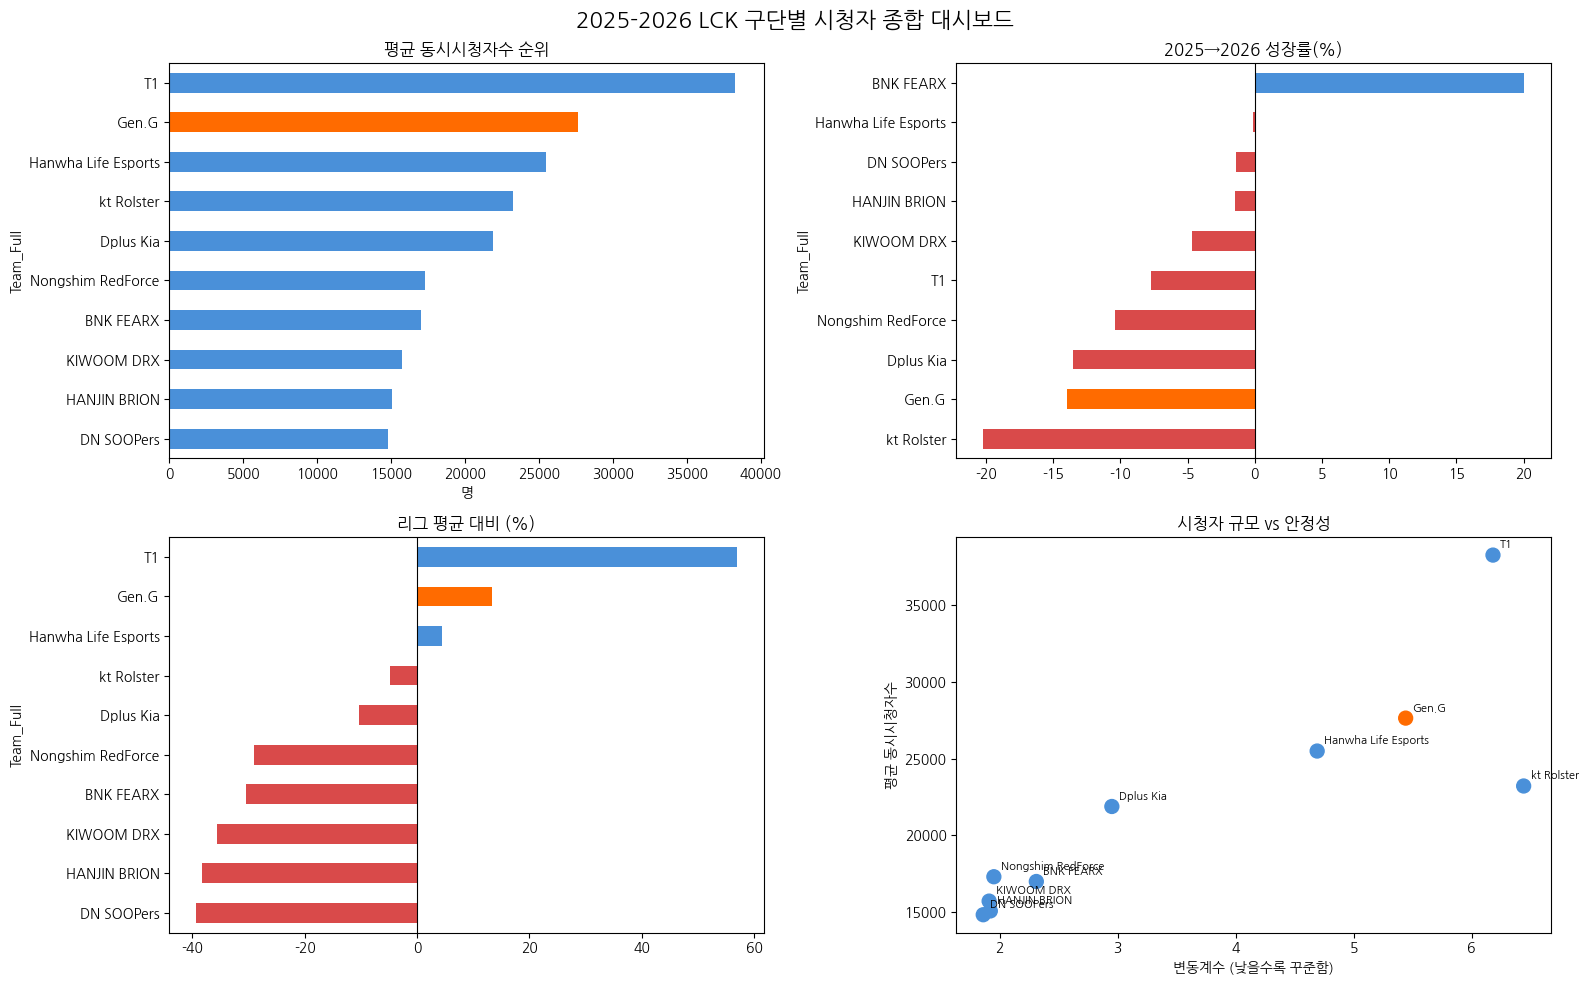

In [33]:
# [셀 24] ★ 4분면 종합 대시보드 시각화
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

!apt-get -qq install fonts-nanum > /dev/null
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('2025-2026 LCK 구단별 시청자 종합 대시보드', fontsize=16, fontweight='bold')

colors = ['#FF6B00' if t=='Gen.G' else '#4A90D9' for t in summary_master.index]

ax1 = axes[0,0]
summary_master['평균동시시청자'].sort_values().plot(kind='barh', ax=ax1, color=colors[::-1])
ax1.set_title('평균 동시시청자수 순위')
ax1.set_xlabel('명')

ax2 = axes[0,1]
growth_sorted = summary_master['YoY_성장률(%)'].sort_values()
bar_colors2 = ['#FF6B00' if t=='Gen.G' else ('#4A90D9' if v>=0 else '#D94A4A') for t,v in growth_sorted.items()]
growth_sorted.plot(kind='barh', ax=ax2, color=bar_colors2)
ax2.set_title('2025→2026 성장률(%)')
ax2.axvline(0, color='black', linewidth=0.8)

ax3 = axes[1,0]
league_pos = summary_master['리그평균대비(%)'].sort_values()
bar_colors3 = ['#FF6B00' if t=='Gen.G' else ('#4A90D9' if v>=0 else '#D94A4A') for t,v in league_pos.items()]
league_pos.plot(kind='barh', ax=ax3, color=bar_colors3)
ax3.set_title('리그 평균 대비 (%)')
ax3.axvline(0, color='black', linewidth=0.8)

ax4 = axes[1,1]
ax4.scatter(summary_master['변동계수'], summary_master['평균동시시청자'], c=colors, s=100)
for team in summary_master.index:
    ax4.annotate(team, (summary_master.loc[team,'변동계수'], summary_master.loc[team,'평균동시시청자']),
                 fontsize=8, xytext=(5,5), textcoords='offset points')
ax4.set_xlabel('변동계수 (낮을수록 꾸준함)')
ax4.set_ylabel('평균 동시시청자수')
ax4.set_title('시청자 규모 vs 안정성')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Gen.G/dashboard_summary.png", dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# ============================================
# 4분면 대시보드 이미지를 엑셀 시트에 삽입
# ============================================
from openpyxl.drawing.image import Image as XLImage

# 셀 24에서 만든 fig를 파일로 저장 (이미 저장했다면 이 줄은 생략 가능)
fig.savefig("/content/drive/MyDrive/Gen.G/dashboard_summary.png", dpi=150, bbox_inches="tight")

# 최종 엑셀 파일 열어서 새 시트에 이미지 삽입
import openpyxl
wb = openpyxl.load_workbook("/content/drive/MyDrive/Gen.G/최종_LCK_시청자_분석.xlsx")

if "Dashboard" in wb.sheetnames:
    del wb["Dashboard"]
ws = wb.create_sheet("Dashboard")
wb.move_sheet("Dashboard", offset=-(len(wb.sheetnames) - 1))  # 맨 앞으로 이동

img = XLImage("/content/drive/MyDrive/Gen.G/dashboard_summary.png")
img.width = 1200   # 원본 비율 유지하려면 원본 크기에 비례해서 조정하세요
img.height = 800
ws.add_image(img, "A1")

wb.save("/content/drive/MyDrive/Gen.G/최종_LCK_시청자_분석.xlsx")
print("Dashboard 시트에 이미지 삽입 완료")

Dashboard 시트에 이미지 삽입 완료


In [35]:
# [셀 25] 24-25-26 리그 전체 트렌드 계산
trend_reference_std = trend_reference.rename(columns={
    'ACU': 'Avg_Viewers',
    'PCU': 'Peak_Viewers_sub'
})
trend_reference_std['Avg_Viewers'] = pd.to_numeric(trend_reference_std['Avg_Viewers'], errors='coerce')
trend_reference_std['Peak_Viewers_sub'] = pd.to_numeric(trend_reference_std['Peak_Viewers_sub'], errors='coerce')

all_years_combined = pd.concat([
    trend_reference_std[['Year', 'Avg_Viewers', 'Peak_Viewers_sub']],
    final[['Year', 'Avg_Viewers', 'Peak_Viewers_sub']]
], ignore_index=True)

yearly_trend = all_years_combined.groupby('Year').agg(
    평균동시시청자=('Avg_Viewers', 'mean'),
    최고동시시청자=('Peak_Viewers_sub', 'max'),
    표본수=('Avg_Viewers', 'count')
).round(0)
yearly_trend['전년대비_평균증감(%)'] = yearly_trend['평균동시시청자'].pct_change().mul(100).round(1)

print(yearly_trend)

      평균동시시청자    최고동시시청자    표본수  전년대비_평균증감(%)
Year                                         
2024  26433.0  2037131.0   2338           NaN
2025  26132.0  7233730.0  19307          -1.1
2026  20635.0  1543277.0   8816         -21.0


In [36]:
# [셀 26]============================================
# 0_설명 시트 내용 만들기
# ============================================
description_rows = [
    ["시트명", "내용 설명"],
    ["", ""],
    ["1_종합요약표", "LCK 10개 구단의 2025~2026년 상반기 시청자 데이터를 구단별로 요약한 표. 순위, 평균/최고 동시시청자수, 리그평균 대비 비율, 전년대비 성장률, 안정성(변동계수)을 한 눈에 볼 수 있음."],
    ["2_24-25-26_리그트렌드", "구단 구분 없이 리그 전체가 2024→2025→2026년 사이 시청자 수가 어떻게 변했는지 보여주는 표. 2024년은 구단별로 못 나누는 데이터라 여기서만 참고용으로 사용."],
    ["3_Raw_Data_2025-2026", "구단별 비교 분석에 실제로 사용된 원본 데이터 (2025~2026 상반기 통합, Worlds+LCK+GLOBAL)."],
    ["4_구단x연도_평균", "구단별, 연도별 평균 동시시청자수를 교차표로 정리."],
    ["4_구단x연도_최고", "구단별, 연도별 최고 동시시청자수를 교차표로 정리."],
    ["5_연도별_순위", "2025년과 2026년 각각의 구단 순위, 순위 변화량."],
    ["5_YoY_성장률", "2025년 대비 2026년 시청자수 증감률(%)."],
    ["5_시청자_안정성", "구단별 시청자수의 변동계수. 낮을수록 경기마다 꾸준히 시청, 높을수록 특정 경기(빅매치)에만 몰림."],
    ["5_스플릿별_비교", "LCK Cup/스프링/Road to MSI 등 시즌 구간별 구단 평균 시청자수."],
    ["5_GenG_최고흥행경기", "Gen.G 경기 중 최고 동시시청자수 Top 5."],
    ["5_GenG_vs_리그평균", "Gen.G 시청자수가 리그 10개 구단 평균 대비 몇 % 높은지/낮은지."],
    ["5_GenG_플랫폼별", "Gen.G 경기가 어느 방송 플랫폼(Twitch, YouTube 등)에서 시청자가 많았는지."],
    ["6_2024_원본데이터", "2024년 원본 데이터. 구단별로 못 나눈 데이터라 리그 전체 트렌드용으로만 참고."],
]

description_notes = [
    ["", ""],
    ["주요 용어 및 분석 기준 안내", ""],
    ["데이터 분석 기간", "2025.01.15 ~ 2026.06.06 (2026 상반기 데이터 확보에 따라 분석 범위를 기존 3월 1일에서 6월 6일까지로 확장)"],
    ["구단명 표기 기준 (풀네임 통일)", "모든 구단은 2026년 최신 공식 풀네임으로 일괄 통일함: Gen.G, BNK FEARX, Dplus Kia, T1, DN SOOPers, KIWOOM DRX, Nongshim RedForce, kt Rolster, HANJIN BRION, Hanwha Life Esports. (분석 범위 확장에 따라 DRX는 키움증권 스폰서십 변경을 반영하여 KIWOOM DRX로 통일 표기함)"],
    ["2026 First Stand(FST) 데이터 안내", "2026 First Stand의 경우 대회 전체 데이터 확보가 불가(결승전 단일 데이터만 존재)하여 데이터 편향 방지를 위해 분석 대상에 포함하지 않음 (해당 기간 공백기 존재)."],
    ["Avg_Viewers (평균 동시시청자수)", "방송 중 평균적으로 동시에 시청한 사람 수. LCK 원본에서는 ACU, Worlds 원본에서는 AMA로 불리던 값을 통일함. 이 지표를 메인으로 사용."],
    ["Peak_Viewers_sub (최고 동시시청자수)", "방송 중 가장 시청자가 많았던 순간의 수. LCK 원본에서는 PCU, Worlds 원본에서는 Peak Viewers로 불리던 값을 통일함. 서브 지표로 참고용."],
    ["Team_Full (구단명)", "2026 최신 공식 풀네임으로 통일한 컬럼. 리그 10개 구단만 포함(해외 참가팀 제외)."],
    ["Source (데이터 출처)", "이 행이 Worlds_2025(2025 월즈), LCK_Master(LCK 국내 시즌), GLOBAL_Master(MSI 등 국제전) 중 어디서 왔는지."],
    ["왜 2024년은 구단별 비교에 없나요?", "2024년 원본 데이터는 하루에 경기가 2개 이상 있으면 시청자수가 두 경기 합산으로 기록되어 있어 구단 구분이 불가능함. 따라서 '리그 전체 트렌드' 참고용으로만 별도 시트에 보관함."],
]

desc_df = pd.DataFrame(description_rows[2:], columns=description_rows[0])
notes_df = pd.DataFrame(description_notes[2:], columns=["항목", "설명"])

In [37]:
# [셀 27] 최종 제출용 파일 하나로 저장
# ============================================
# 최종 제출용 파일 저장 (설명 시트 포함)
# ============================================
with pd.ExcelWriter("/content/drive/MyDrive/Gen.G/최종_LCK_시청자_분석.xlsx", engine="openpyxl") as writer:
    # 0. 설명 시트 (맨 앞)
    desc_df.to_excel(writer, sheet_name="0_설명", index=False, startrow=0)
    notes_df.to_excel(writer, sheet_name="0_설명", index=False, startrow=len(desc_df)+3)

    # 1~6. 기존 시트들
    summary_master.to_excel(writer, sheet_name="1_종합요약표")
    yearly_trend.to_excel(writer, sheet_name="2_24-25-26_리그트렌드")
    final.to_excel(writer, sheet_name="3_Raw_Data_2025-2026", index=False)
    pivot_avg.to_excel(writer, sheet_name="4_구단x연도_평균")
    pivot_peak.to_excel(writer, sheet_name="4_구단x연도_최고")
    rank_by_year.to_excel(writer, sheet_name="5_연도별_순위")
    growth.to_excel(writer, sheet_name="5_YoY_성장률")
    stability.to_excel(writer, sheet_name="5_시청자_안정성")
    split_summary.to_excel(writer, sheet_name="5_스플릿별_비교")
    geng_top5.to_excel(writer, sheet_name="5_GenG_최고흥행경기", index=False)
    comparison.to_excel(writer, sheet_name="5_GenG_vs_리그평균")
    platform_summary.to_excel(writer, sheet_name="5_GenG_플랫폼별")
    trend_reference.to_excel(writer, sheet_name="6_2024_원본데이터", index=False)

    # 시트 순서를 0번이 맨 앞에 오도록 정렬
    workbook = writer.book
    workbook.move_sheet("0_설명", offset=-len(workbook.sheetnames))

print("최종 파일 저장 완료 (설명 시트 포함): 최종_LCK_시청자_분석.xlsx")

최종 파일 저장 완료 (설명 시트 포함): 최종_LCK_시청자_분석.xlsx


In [38]:
# [셀 28]
# ============================================
# 주요 시트 헤더에 설명 코멘트(메모) 추가
# ============================================
from openpyxl import load_workbook
from openpyxl.comments import Comment

wb = load_workbook("/content/drive/MyDrive/Gen.G/최종_LCK_시청자_분석.xlsx")

# 컬럼명 -> 설명 매핑
header_comments = {
    "순위": (
        "평균 동시시청자수 기준 전체 구단 순위 (1위가 가장 많이 봄)"
    ),
    "평균동시시청자": (
        "ACU(LCK)/AMA(Worlds) 통일 지표. 방송 중 평균적으로 동시 시청한 인원"
    ),
    "최고동시시청자": (
        "PCU(LCK)/Peak Viewers(Worlds) 통일 지표. 방송 중 시청자가 가장 많았던"
        " 순간"
    ),
    "리그평균대비(%)": (
        "이 구단 평균이 10개 구단 전체 평균보다 몇 % 높은지/낮은지 (양수=평균"
        " 이상)"
    ),
    "2025_평균": "2025년 한 해 평균 동시시청자수",
    "2026_평균": (
        "2026년 상반기(6월 14일 RTM 결승전까지) 평균 동시시청자수 (2026 FST"
        " 제외)"
    ),  # ← 수정
    "YoY_성장률(%)": (
        "2025년 대비 2026년 시청자수 증감률. 양수=성장, 음수=하락"
    ),
    "변동계수": (
        "표준편차/평균값. 낮을수록 경기마다 꾸준히 시청, 높을수록 특정"
        " 빅매치에만 시청자가 몰림"
    ),
    "경기표본수": (
        "이 구단의 시청자 데이터가 집계된 행(채널×경기) 개수. 성적이 좋을수록"
        " 표본 증가"
    ),
    "Team_Full": (
        "2026 최신 공식 풀네임 (예: KIWOOM DRX, HANJIN BRION, kt Rolster"
        " 등)"
    ),  # ← 수정
    "Avg_Viewers": "평균 동시시청자수 (ACU/AMA 통일 지표)",
    "Peak_Viewers_sub": "최고 동시시청자수 (PCU/Peak Viewers 통일 서브 지표)",
    "Source": (
        "데이터 출처: Worlds_2025(월즈) / LCK_Master(국내 시즌) /"
        " GLOBAL_Master(국제전)"
    ),
}

target_sheets = ["1_종합요약표", "3_Raw_Data_2025-2026", "4_구단x연도_평균", "4_구단x연도_최고"]

for sheet_name in target_sheets:
    if sheet_name not in wb.sheetnames:
        continue
    ws = wb[sheet_name]
    header_row = 1
    for cell in ws[header_row]:
        if cell.value in header_comments:
            cell.comment = Comment(header_comments[cell.value], "설명")

wb.save("/content/drive/MyDrive/Gen.G/최종_LCK_시청자_분석.xlsx")
print("헤더 설명 코멘트 추가 완료")

헤더 설명 코멘트 추가 완료


In [39]:
# ============================================
# 시트별 해석 문구 자동 생성 + 보고서 형태로 저장
# ============================================
from openpyxl import Workbook
from openpyxl.styles import Font, Alignment, PatternFill
from openpyxl.utils.dataframe import dataframe_to_rows

# --- 실제 데이터에서 핵심 수치 뽑아서 문장 자동 생성 ---
top_team = summary_master.index[0]
top_avg = int(summary_master.loc[top_team, '평균동시시청자'])
geng_rank = int(summary_master.loc['Gen.G', '순위'])
geng_pct = summary_master.loc['Gen.G', '리그평균대비(%)']
geng_growth = summary_master.loc['Gen.G', 'YoY_성장률(%)']

fastest_growing = growth['YoY_성장률(%)'].idxmax()
fastest_growth_pct = growth['YoY_성장률(%)'].max()
declining_teams = growth[growth['YoY_성장률(%)'] < 0].index.tolist()

most_stable = stability.index[0]
least_stable = stability.index[-1]

trend_2024 = int(yearly_trend.loc[2024, '평균동시시청자']) if 2024 in yearly_trend.index else None
trend_2025 = int(yearly_trend.loc[2025, '평균동시시청자']) if 2025 in yearly_trend.index else None
trend_2026 = int(yearly_trend.loc[2026, '평균동시시청자']) if 2026 in yearly_trend.index else None
trend_2526_pct = yearly_trend.loc[2026, '전년대비_평균증감(%)'] if 2026 in yearly_trend.index else None

geng_top_match = geng_top5.iloc[0]

# --- 시트별 제목 + 해석 문구 정의 ---
sheet_texts = {
    "1_종합요약표": {
        "title": "구단별 시청자 종합 요약",
        "desc": "LCK 10개 구단의 2025~2026년 시청자 데이터를 순위·평균/최고 시청자수·리그평균 대비·성장률·안정성 기준으로 종합 정리한 표입니다.",
        "insight": (
            f"■ {top_team}이(가) 평균 동시시청자수 {top_avg:,}명으로 전체 1위입니다.\n"
            f"■ Gen.G는 전체 {geng_rank}위이며, 리그 평균 대비 {geng_pct:+.1f}%, "
            f"전년 대비 시청자수 증감률은 {geng_growth:+.1f}%입니다.\n"
            f"■ 2025→2026년 사이 가장 성장한 구단은 {fastest_growing}({fastest_growth_pct:+.1f}%)이며, "
            f"{', '.join(declining_teams) if declining_teams else '하락한 구단은 없습니다'}은(는) 전년 대비 시청자수가 감소했습니다.\n"
            f"■ 시청자수가 가장 안정적인(꾸준히 시청되는) 구단은 {most_stable}, "
            f"가장 변동이 큰(특정 경기에 시청자가 몰리는) 구단은 {least_stable}입니다."
        )
    },
    "2_24-25-26_리그트렌드": {
        "title": "LCK 리그 전체 시청자 트렌드 (2024-2026)",
        "desc": "구단 구분 없이 리그 전체 시청자수가 3개년 사이 어떻게 변했는지 보여줍니다. 2024년은 구단별 비교가 불가능한 데이터라 이 트렌드에서만 참고용으로 포함했습니다.",
        "insight": (
            f"■ 리그 전체 평균 동시시청자수는 2024년 {trend_2024:,}명 → 2025년 {trend_2025:,}명"
            + (f" → 2026년 {trend_2026:,}명" if trend_2026 else "") + "으로 변화했습니다.\n"
            + (f"■ 2025년 대비 2026년은 {trend_2526_pct:+.1f}% 변화했습니다.\n" if trend_2526_pct is not None else "")
            + "■ 2026년 수치는 시즌이 진행 중인 시점(9월 초)까지의 데이터 기준이라, 시즌 완주 후 최종 수치와 다를 수 있습니다."
        )
    },
    "3_Raw_Data_2025-2026": {
        "title": "구단별 비교 분석 원본 데이터 (2025-2026)",
        "desc": "구단별 비교에 실제로 사용된 원본 데이터입니다. Worlds 2025, LCK 국내 시즌, MSI/First Stand 등 국제전 데이터를 하나로 통합했습니다. (Source 컬럼으로 출처 구분)",
        "insight": f"■ 총 {len(final):,}개 행, {final['Team_Full'].nunique()}개 구단, {final['Source'].nunique()}개 데이터 출처로 구성되어 있습니다."
    },
    "4_구단x연도_평균": {
        "title": "구단 × 연도별 평균 동시시청자수",
        "desc": "각 구단이 연도별로 평균 몇 명의 동시시청자를 기록했는지 교차 비교한 표입니다.",
        "insight": f"■ 표에서 오른쪽 '전체평균' 컬럼 기준 내림차순 정렬되어 있어, 위에서 아래로 갈수록 시청자수가 적은 구단입니다."
    },
    "4_구단x연도_최고": {
        "title": "구단 × 연도별 최고 동시시청자수",
        "desc": "각 구단의 연도별 최고 기록(가장 흥행했던 순간)을 비교한 표입니다.",
        "insight": "■ 평균이 아닌 '한 순간의 최고 기록'이라, 빅매치나 결승전 등 특정 경기의 영향을 크게 받습니다."
    },
    "5_연도별_순위": {
        "title": "연도별 구단 순위 변화",
        "desc": "2025년과 2026년 각각의 구단 순위와 순위 변동폭을 보여줍니다.",
        "insight": "■ '순위변화(25→26)' 컬럼이 양수면 순위가 오른 것(숫자가 작아짐), 음수면 순위가 내려간 것입니다."
    },
    "5_YoY_성장률": {
        "title": "전년 대비 시청자수 성장률",
        "desc": "2025년 대비 2026년 시청자수가 몇 % 증가/감소했는지 구단별로 정리했습니다.",
        "insight": f"■ {fastest_growing} 구단이 {fastest_growth_pct:+.1f}%로 가장 큰 성장폭을 보였습니다."
    },
    "5_시청자_안정성": {
        "title": "구단별 시청자수 안정성",
        "desc": "변동계수(표준편차÷평균)로 구단의 시청 패턴을 분석했습니다.",
        "insight": (
            f"■ {most_stable}은(는) 변동계수가 낮아 경기마다 꾸준한 시청자를 확보하는 편이고, "
            f"{least_stable}은(는) 변동계수가 높아 특정 빅매치에 시청자가 몰리는 경향이 있습니다."
        )
    },
    "5_스플릿별_비교": {
        "title": "시즌 구간(스플릿)별 구단 성적",
        "desc": "스프링/서머/CUP 등 시즌 구간별로 구단 평균 시청자수를 비교했습니다.",
        "insight": f"■ Gen.G가 가장 흥행한 구간은 '{geng_split.index[0]}'입니다." if 'geng_split' in dir() else ""
    },
    "5_GenG_최고흥행경기": {
        "title": "Gen.G 역대 최고 흥행 경기 Top 5",
        "desc": "Gen.G가 출전한 경기 중 최고 동시시청자수 기준 상위 5개 경기입니다.",
        "insight": f"■ 최고 기록은 {geng_top_match['Date']}, 최고동접 {int(geng_top_match['Peak_Viewers_sub']):,}명입니다."
    },
    "5_GenG_vs_리그평균": {
        "title": "Gen.G vs 리그 평균 비교",
        "desc": "Gen.G의 시청자수가 리그 10개 구단 평균 대비 얼마나 높은지/낮은지 연도별로 비교했습니다.",
        "insight": f"■ Gen.G는 리그 평균 대비 {geng_pct:+.1f}%를 기록 중입니다 (양수=평균 이상)."
    },
    "5_GenG_플랫폼별": {
        "title": "Gen.G 플랫폼별 시청자 성적",
        "desc": "Gen.G 경기가 어느 방송 플랫폼(Twitch, YouTube, SOOP 등)에서 시청자가 많았는지 비교했습니다.",
        "insight": f"■ Gen.G 시청자가 가장 많이 몰리는 플랫폼은 '{platform_summary.index[0]}'입니다."
    },
    "6_2024_원본데이터": {
        "title": "2024년 원본 데이터 (참고용)",
        "desc": "2024년은 하루에 경기가 2개 이상 있으면 시청자수가 합산 기록되어 있어 구단별로 나눌 수 없습니다. 리그 전체 트렌드 참고용으로만 사용하고, 구단별 비교에는 포함하지 않았습니다.",
        "insight": f"■ 총 {len(trend_reference):,}행이며, 이 중 팀 정보가 부분적으로 채워진 행(16일치, 검색으로 확인)과 원천적으로 채울 수 없는 행이 섞여 있습니다."
    },
}

print("해석 문구 생성 완료")

해석 문구 생성 완료


In [40]:
# ============================================
# 보고서 형태로 엑셀 저장 (제목 + 설명 + 인사이트 + 표)
# ============================================

from openpyxl.utils import get_column_letter

def write_report_sheet(wb, sheet_name, df, sheet_texts, index=True):
    ws = wb.create_sheet(sheet_name)
    info = sheet_texts.get(sheet_name, {"title": sheet_name, "desc": "", "insight": ""})

    n_cols = max(6, df.shape[1] + (1 if index else 0))

    # 제목
    ws.cell(row=1, column=1, value=info["title"])
    ws.cell(row=1, column=1).font = Font(bold=True, size=14, color="FFFFFF")
    ws.cell(row=1, column=1).fill = PatternFill("solid", fgColor="4A90D9")
    ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=n_cols)

    # 설명
    ws.cell(row=2, column=1, value=f"📋 {info['desc']}")
    ws.cell(row=2, column=1).font = Font(italic=True, size=10, color="555555")
    ws.merge_cells(start_row=2, start_column=1, end_row=2, end_column=n_cols)
    ws.row_dimensions[2].height = 30
    ws.cell(row=2, column=1).alignment = Alignment(wrap_text=True, vertical="top")

    # 인사이트
    ws.cell(row=3, column=1, value=info["insight"])
    ws.cell(row=3, column=1).font = Font(size=10, color="1A5D1A")
    ws.cell(row=3, column=1).fill = PatternFill("solid", fgColor="EAF7EA")
    ws.merge_cells(start_row=3, start_column=1, end_row=3, end_column=n_cols)
    ws.row_dimensions[3].height = 15 * (info["insight"].count("\n") + 2)
    ws.cell(row=3, column=1).alignment = Alignment(wrap_text=True, vertical="top")

    table_start_row = 5

    # 표 삽입
    max_col = 0
    rows = dataframe_to_rows(df, index=index, header=True)
    for r_idx, row in enumerate(rows, start=table_start_row):
        for c_idx, value in enumerate(row, start=1):
            cell = ws.cell(row=r_idx, column=c_idx, value=value)
            if r_idx == table_start_row:
                cell.font = Font(bold=True)
                cell.fill = PatternFill("solid", fgColor="D9E6F5")
            max_col = max(max_col, c_idx)

    # 컬럼 너비 자동 조정 - 병합 셀 문제 피하려고 컬럼 인덱스 기반으로 직접 계산
    for col_idx in range(1, max_col + 1):
        col_letter = get_column_letter(col_idx)
        max_len = 0
        for row_idx in range(table_start_row, ws.max_row + 1):
            cell_value = ws.cell(row=row_idx, column=col_idx).value
            if cell_value is not None:
                max_len = max(max_len, len(str(cell_value)))
        ws.column_dimensions[col_letter].width = min(max(max_len + 2, 10), 40)

    return ws


wb = Workbook()
wb.remove(wb.active)  # 기본 시트 제거

write_report_sheet(wb, "1_종합요약표", summary_master, sheet_texts)
write_report_sheet(wb, "2_24-25-26_리그트렌드", yearly_trend, sheet_texts)
write_report_sheet(wb, "3_Raw_Data_2025-2026", final, sheet_texts, index=False)
write_report_sheet(wb, "4_구단x연도_평균", pivot_avg, sheet_texts)
write_report_sheet(wb, "4_구단x연도_최고", pivot_peak, sheet_texts)
write_report_sheet(wb, "5_연도별_순위", rank_by_year, sheet_texts)
write_report_sheet(wb, "5_YoY_성장률", growth, sheet_texts)
write_report_sheet(wb, "5_시청자_안정성", stability, sheet_texts)
write_report_sheet(wb, "5_스플릿별_비교", split_summary, sheet_texts)
write_report_sheet(wb, "5_GenG_최고흥행경기", geng_top5, sheet_texts, index=False)
write_report_sheet(wb, "5_GenG_vs_리그평균", comparison, sheet_texts)
write_report_sheet(wb, "5_GenG_플랫폼별", platform_summary, sheet_texts)
write_report_sheet(wb, "6_2024_원본데이터", trend_reference, sheet_texts, index=False)

# ============================================
# Gen.G 원페이지 하이라이트 시트
# ============================================
from openpyxl.styles import Border, Side

def kpi_card(ws, row, col, value, label, fill_color="4A90D9", value_color="FFFFFF", span=2):
    """숫자 카드 하나 그리기 (2x2 병합 블록)"""
    ws.merge_cells(start_row=row, start_column=col, end_row=row+1, end_column=col+span-1)
    cell = ws.cell(row=row, column=col, value=value)
    cell.font = Font(bold=True, size=20, color=value_color)
    cell.fill = PatternFill("solid", fgColor=fill_color)
    cell.alignment = Alignment(horizontal="center", vertical="center")

    ws.merge_cells(start_row=row+2, start_column=col, end_row=row+2, end_column=col+span-1)
    label_cell = ws.cell(row=row+2, column=col, value=label)
    label_cell.font = Font(size=10, color="555555", bold=True)
    label_cell.alignment = Alignment(horizontal="center", vertical="center")
    label_cell.fill = PatternFill("solid", fgColor="F2F2F2")


# --- Gen.G 핵심 수치 계산 ---
geng_row = summary_master.loc['Gen.G']
geng_avg = int(geng_row['평균동시시청자'])
geng_peak = int(geng_row['최고동시시청자'])
geng_rank = int(geng_row['순위'])
geng_pct = geng_row['리그평균대비(%)']
geng_growth = geng_row['YoY_성장률(%)']
geng_platforms = final[final['Team_Full']=='Gen.G']['Platform'].nunique()
geng_matches_count = int(geng_row['경기표본수'])

# 라이벌 비교 대상 (1위가 Gen.G면 2위, 아니면 1위)
rival_team = summary_master.index[1] if summary_master.index[0]=='Gen.G' else summary_master.index[0]
rival_avg = int(summary_master.loc[rival_team, '평균동시시청자'])

wb_sheets = wb.sheetnames
ws = wb.create_sheet("1_GenG_핵심요약")
wb.move_sheet("1_GenG_핵심요약", offset=-(len(wb.sheetnames) - wb.sheetnames.index("1_종합요약표") - 1))

# ── 타이틀 배너 ──
ws.merge_cells("A1:L2")
title_cell = ws.cell(row=1, column=1, value="Gen.G  |  2025-2026 시청자 데이터 하이라이트")
title_cell.font = Font(bold=True, size=20, color="FFFFFF")
title_cell.fill = PatternFill("solid", fgColor="1B1B3A")
title_cell.alignment = Alignment(horizontal="center", vertical="center")

ws.merge_cells("A3:L3")
sub_cell = ws.cell(
    row=3,
    column=1,
    value=(
        "2025~2026 상반기 LCK · Worlds · MSI 통합 데이터 기준 "
        "(2026 First Stand는 분석 제외)"
    ),
)
sub_cell.font = Font(italic=True, size=10, color="777777")
sub_cell.alignment = Alignment(horizontal="center")
ws.row_dimensions[3].height = 20

# ── KPI 카드 4개 (한 줄) ──
kpi_card(ws, 5, 1,  f"#{geng_rank} / 10", "LCK 리그 내 시청자 순위", fill_color="FF6B00")
kpi_card(ws, 5, 4,  f"{geng_avg:,}명", "평균 동시시청자수", fill_color="1B1B3A")
kpi_card(ws, 5, 7,  f"{geng_peak:,}명", "역대 최고 동시시청자", fill_color="1B1B3A")
kpi_card(ws, 5, 10, f"{geng_pct:+.1f}%", "리그 평균 대비", fill_color="2E8B57" if geng_pct>=0 else "C0392B")

# ── KPI 카드 4개 (둘째 줄) ──
kpi_card(ws, 9, 1,  f"{geng_growth:+.1f}%", "전년대비 성장률 (25→26)", fill_color="2E8B57" if geng_growth>=0 else "C0392B")
kpi_card(ws, 9, 4,  f"{geng_matches_count:,}개", "누적 경기·채널 표본 수", fill_color="1B1B3A")
kpi_card(ws, 9, 7,  f"{geng_platforms}개", "송출 플랫폼 수", fill_color="1B1B3A")
kpi_card(ws, 9, 10, "MSI 2우승", "국제대회 성과 (2024·2025 MSI 연속 우승)", fill_color="B8860B")

current_row = 13

# ── 컴팩트 비교표 1: Gen.G vs 라이벌 vs 리그평균 ──
ws.cell(row=current_row, column=1, value="① Gen.G vs 주요 경쟁 구단 비교").font = Font(bold=True, size=13, color="1B1B3A")
current_row += 1

comp_headers = ["구분", "Gen.G", rival_team, "리그 평균(10개 구단)"]
comp_values = [
    "평균 동시시청자수",
    f"{geng_avg:,}",
    f"{rival_avg:,}",
    f"{int(summary_master['평균동시시청자'].mean()):,}",
]
for c_idx, h in enumerate(comp_headers, start=1):
    cell = ws.cell(row=current_row, column=c_idx, value=h)
    cell.font = Font(bold=True, color="FFFFFF")
    cell.fill = PatternFill("solid", fgColor="4A90D9")
current_row += 1
for c_idx, v in enumerate(comp_values, start=1):
    ws.cell(row=current_row, column=c_idx, value=v)
current_row += 3

# ── 컴팩트 비교표 2: Gen.G 최고 흥행 경기 Top 3 ──
ws.cell(row=current_row, column=1, value="② Gen.G 최고 흥행 경기 TOP 3").font = Font(bold=True, size=13, color="1B1B3A")
current_row += 1

top3_headers = ["날짜", "대회", "최고 동시시청자"]
for c_idx, h in enumerate(top3_headers, start=1):
    cell = ws.cell(row=current_row, column=c_idx, value=h)
    cell.font = Font(bold=True, color="FFFFFF")
    cell.fill = PatternFill("solid", fgColor="4A90D9")
current_row += 1

for _, row in geng_top5.head(3).iterrows():
    ws.cell(row=current_row, column=1, value=str(row['Date'])[:10])
    ws.cell(row=current_row, column=2, value=row.get('대회정보', row.get('Source','')))
    ws.cell(row=current_row, column=3, value=f"{int(row['Peak_Viewers_sub']):,}명")
    current_row += 1
current_row += 2

# ── 컴팩트 비교표 3: 플랫폼별 TOP 3 ──
ws.cell(row=current_row, column=1, value="③ Gen.G 플랫폼별 평균 시청자 TOP 3").font = Font(bold=True, size=13, color="1B1B3A")
current_row += 1

plat_headers = ["플랫폼", "평균 동시시청자", "표본 수"]
for c_idx, h in enumerate(plat_headers, start=1):
    cell = ws.cell(row=current_row, column=c_idx, value=h)
    cell.font = Font(bold=True, color="FFFFFF")
    cell.fill = PatternFill("solid", fgColor="4A90D9")
current_row += 1

for plat_name, plat_row in platform_summary.head(3).iterrows():
    ws.cell(row=current_row, column=1, value=plat_name)
    ws.cell(row=current_row, column=2, value=f"{int(plat_row['mean']):,}명")
    ws.cell(row=current_row, column=3, value=int(plat_row['count']))
    current_row += 1
current_row += 2

# ── 하단 요약 코멘트 (자동 생성 문장) ──
ws.merge_cells(start_row=current_row, start_column=1, end_row=current_row+2, end_column=12)
summary_text = (
    f"Gen.G는 LCK 10개 구단 중 시청자수 {geng_rank}위(리그 평균 대비 {geng_pct:+.1f}%)를 기록 중이며, "
    f"2025년 대비 2026년 시청자수는 {geng_growth:+.1f}% "
    f"{'성장' if geng_growth >= 0 else '감소'}했습니다. "
    f"2024·2025년 MSI 2연패를 포함해 국제무대에서도 지속적인 성과를 내고 있으며, "
    f"{geng_platforms}개 플랫폼을 통해 글로벌 팬층에 도달하고 있습니다."
)
comment_cell = ws.cell(row=current_row, column=1, value="💬 " + summary_text)
comment_cell.font = Font(size=11, italic=True, color="1B1B3A")
comment_cell.fill = PatternFill("solid", fgColor="FFF4E5")
comment_cell.alignment = Alignment(wrap_text=True, vertical="top")

# 컬럼 너비 정리
for col_idx in range(1, 13):
    ws.column_dimensions[get_column_letter(col_idx)].width = 14

print("Gen.G 핵심요약 시트 생성 완료")

wb.save("/content/drive/MyDrive/Gen.G/최종_LCK_시청자_분석.xlsx")
print("보고서 형태 최종 파일 저장 완료!")

Gen.G 핵심요약 시트 생성 완료
보고서 형태 최종 파일 저장 완료!


In [41]:
# ============================================
# 2026 First Stand 별도 데이터프레임 (Stream Hatchet PDF 출처)
# final과는 독립적으로 보관 — 나중에 옵션 1(참고용) or 3(통합) 결정
# ============================================

first_stand_2026_manual = pd.DataFrame([
    {"Team": "G2",   "Team_Full": "G2 Esports",       "Record": "10-6", "AMA_Agg": 1_820_000, "Peak_Agg": 3_590_000},
    {"Team": "BLG",  "Team_Full": "Bilibili Gaming",  "Record": "12-3", "AMA_Agg": 1_840_000, "Peak_Agg": 3_590_000},
    {"Team": "BFX",  "Team_Full": "BNK FEARX",        "Record": "5-6",  "AMA_Agg": 1_160_000, "Peak_Agg": 1_730_000},
    {"Team": "GEN",  "Team_Full": "Gen.G",            "Record": "6-3",  "AMA_Agg": 1_700_000, "Peak_Agg": 3_060_000},
    {"Team": "JDG",  "Team_Full": "JD Gaming",        "Record": "6-7",  "AMA_Agg": 1_050_000, "Peak_Agg": 2_020_000},
    {"Team": "LYON", "Team_Full": "LYON",             "Record": "4-8",  "AMA_Agg": 773_000,   "Peak_Agg": 1_320_000},
    {"Team": "TSW",  "Team_Full": "TSW",              "Record": "0-6",  "AMA_Agg": 646_000,   "Peak_Agg": 831_000},
    {"Team": "LLL",  "Team_Full": "LLL",              "Record": "2-6",  "AMA_Agg": 637_000,   "Peak_Agg": 1_320_000},
])

# 메타데이터 명시 (나중에 봤을 때 헷갈리지 않도록)
first_stand_2026_manual["Stage"] = "First_Stand_2026"
first_stand_2026_manual["Source"] = "Stream_Hatchet_PDF"
first_stand_2026_manual["Granularity"] = "Tournament-wide, all-platform aggregate (NOT per-channel)"
first_stand_2026_manual["Note"] = "final의 Avg_Viewers/Peak_Viewers_sub와 집계 단위가 다름 - 직접 비교 금지"

print(first_stand_2026_manual)

# 별도 파일로도 저장 (final과 섞이지 않게)
first_stand_2026_manual.to_excel("/content/drive/MyDrive/Gen.G/first_stand_2026_manual.xlsx", index=False)

   Team        Team_Full Record  AMA_Agg  Peak_Agg             Stage  \
0    G2       G2 Esports   10-6  1820000   3590000  First_Stand_2026   
1   BLG  Bilibili Gaming   12-3  1840000   3590000  First_Stand_2026   
2   BFX        BNK FEARX    5-6  1160000   1730000  First_Stand_2026   
3   GEN            Gen.G    6-3  1700000   3060000  First_Stand_2026   
4   JDG        JD Gaming    6-7  1050000   2020000  First_Stand_2026   
5  LYON             LYON    4-8   773000   1320000  First_Stand_2026   
6   TSW              TSW    0-6   646000    831000  First_Stand_2026   
7   LLL              LLL    2-6   637000   1320000  First_Stand_2026   

               Source                                        Granularity  \
0  Stream_Hatchet_PDF  Tournament-wide, all-platform aggregate (NOT p...   
1  Stream_Hatchet_PDF  Tournament-wide, all-platform aggregate (NOT p...   
2  Stream_Hatchet_PDF  Tournament-wide, all-platform aggregate (NOT p...   
3  Stream_Hatchet_PDF  Tournament-wide, all-pla

In [42]:
# ============================================
# 2026 First Stand Finals 전체 데이터 추출 (Stream Hatchet PDF)
# ============================================

# --- 1. 경기별 데이터 (Matches) ---
fs2026_matches = pd.DataFrame([
    {"Match": "G2 vs BLG", "Datetime_PST": "2026-03-22 06:17", "Duration_min": 40, "Peak_Viewers": 3_330_000, "AMA": 2_780_000, "Costream_pct": 23.0, "Top_Channel": "Riot Games China"},
    {"Match": "G2 vs BLG", "Datetime_PST": "2026-03-22 07:15", "Duration_min": 41, "Peak_Viewers": 3_590_000, "AMA": 3_360_000, "Costream_pct": 23.6, "Top_Channel": "Riot Games China"},
    {"Match": "BLG vs G2", "Datetime_PST": "2026-03-22 08:16", "Duration_min": 30, "Peak_Viewers": 3_430_000, "AMA": 3_280_000, "Costream_pct": 24.1, "Top_Channel": "Riot Games China"},
    {"Match": "BLG vs G2", "Datetime_PST": "2026-03-22 09:05", "Duration_min": 28, "Peak_Viewers": 2_850_000, "AMA": 2_400_000, "Costream_pct": 33.4, "Top_Channel": "Riot Games China"},
])
fs2026_matches["Stage"] = "First_Stand_2026"
fs2026_matches["Source"] = "Stream_Hatchet_PDF"

# --- 2. 구단별 시청자 성과 (Team Viewership, All Event 기준) ---
fs2026_teams = pd.DataFrame([
    {"Team": "G2",   "Team_Full": "G2 Esports",      "WL_AllEvent": "10-6", "AMA_AllEvent": 1_820_000, "Peak_AllEvent": 3_590_000},
    {"Team": "BLG",  "Team_Full": "Bilibili Gaming",  "WL_AllEvent": "12-3", "AMA_AllEvent": 1_840_000, "Peak_AllEvent": 3_590_000},
    {"Team": "BFX",  "Team_Full": "BNK FEARX",        "WL_AllEvent": "5-6",  "AMA_AllEvent": 1_160_000, "Peak_AllEvent": 1_730_000},
    {"Team": "GEN",  "Team_Full": "Gen.G",            "WL_AllEvent": "6-3",  "AMA_AllEvent": 1_700_000, "Peak_AllEvent": 3_060_000},
    {"Team": "JDG",  "Team_Full": "JD Gaming",        "WL_AllEvent": "6-7",  "AMA_AllEvent": 1_050_000, "Peak_AllEvent": 2_020_000},
    {"Team": "LYON", "Team_Full": "LYON",             "WL_AllEvent": "4-8",  "AMA_AllEvent": 773_000,   "Peak_AllEvent": 1_320_000},
    {"Team": "TSW",  "Team_Full": "TSW",              "WL_AllEvent": "0-6",  "AMA_AllEvent": 646_000,   "Peak_AllEvent": 831_000},
    {"Team": "LLL",  "Team_Full": "LLL",              "WL_AllEvent": "2-6",  "AMA_AllEvent": 637_000,   "Peak_AllEvent": 1_320_000},
])
fs2026_teams["Stage"] = "First_Stand_2026"
fs2026_teams["Source"] = "Stream_Hatchet_PDF"

# --- 3. 플랫폼별 성과 (Platforms, 전체 대회 기준) ---
fs2026_platforms = pd.DataFrame([
    {"Platform": "Bilibili",              "Peak": 2_870_000, "Peak_YoY_pct": 293.7, "AMA": 2_530_000, "AMA_YoY_pct": 558.7, "Top_Language": "Mandarin"},
    {"Platform": "Huya TV",                "Peak": 2_940_000, "Peak_YoY_pct": 192.9, "AMA": 2_330_000, "AMA_YoY_pct": 182.2, "Top_Language": "Mandarin"},
    {"Platform": "Sina Weibo",              "Peak": 1_450_000, "Peak_YoY_pct": 20.3,  "AMA": 606_000,   "AMA_YoY_pct": 20.3,  "Top_Language": "Mandarin"},
    {"Platform": "Twitch",                  "Peak": 645_000,   "Peak_YoY_pct": 14.6,  "AMA": 463_000,   "AMA_YoY_pct": 17.4,  "Top_Language": "English"},
    {"Platform": "YouTube",                 "Peak": 676_000,   "Peak_YoY_pct": 77.8,  "AMA": 421_000,   "AMA_YoY_pct": 67.7,  "Top_Language": "Vietnamese"},
    {"Platform": "Tencent Official Channel","Peak": 1_570_000, "Peak_YoY_pct": 198.0, "AMA": 374_000,   "AMA_YoY_pct": 63.7,  "Top_Language": "Mandarin"},
    {"Platform": "Channels",                "Peak": 507_000,   "Peak_YoY_pct": 92.5,  "AMA": 245_000,   "AMA_YoY_pct": 93.4,  "Top_Language": "Mandarin"},
    {"Platform": "Chzzk (Naver)",           "Peak": 89_000,    "Peak_YoY_pct": 29.6,  "AMA": 62_000,    "AMA_YoY_pct": 31.2,  "Top_Language": "Korean"},
    {"Platform": "Soop",                    "Peak": 76_000,    "Peak_YoY_pct": 5.1,   "AMA": 60_000,    "AMA_YoY_pct": 13.1,  "Top_Language": "Korean"},
    {"Platform": "Tencent Video",           "Peak": 56_000,    "Peak_YoY_pct": 4.2,   "AMA": 45_000,    "AMA_YoY_pct": 99.5,  "Top_Language": "Mandarin"},
    {"Platform": "TikTok",                  "Peak": 40_000,    "Peak_YoY_pct": 87.9,  "AMA": 21_000,    "AMA_YoY_pct": 90.9,  "Top_Language": "Vietnamese"},
    {"Platform": "Trovo",                   "Peak": 95,        "Peak_YoY_pct": None,  "AMA": 76,        "AMA_YoY_pct": None,  "Top_Language": "Russian"},
    {"Platform": "Facebook",                "Peak": 153,       "Peak_YoY_pct": None,  "AMA": 64,        "AMA_YoY_pct": None,  "Top_Language": "Vietnamese"},
])
fs2026_platforms["Stage"] = "First_Stand_2026"
fs2026_platforms["Source"] = "Stream_Hatchet_PDF"

# --- 4. 언어별 성과 (Languages) ---
fs2026_languages = pd.DataFrame([
    {"Language": "Mandarin (Chinese Platform)", "Peak": 9_400_000, "Peak_YoY_pct": 148.5, "AMA": 6_130_000, "AMA_YoY_pct": 193.2, "Top_Channel": "Riot Games China"},
    {"Language": "English",                     "Peak": 436_000,   "Peak_YoY_pct": 70.9,  "AMA": 304_000,   "AMA_YoY_pct": 65.5,  "Top_Channel": "Caedrel"},
    {"Language": "Korean",                       "Peak": 257_000,   "Peak_YoY_pct": -2.4,  "AMA": 180_000,   "AMA_YoY_pct": -2.3,  "Top_Channel": "LCK"},
    {"Language": "Vietnamese",                    "Peak": 226_000,   "Peak_YoY_pct": 80.2,  "AMA": 142_000,   "AMA_YoY_pct": 85.9,  "Top_Channel": "Hoàng Luân"},
    {"Language": "Spanish",                       "Peak": 136_000,   "Peak_YoY_pct": 204.7, "AMA": 92_000,    "AMA_YoY_pct": 221.5, "Top_Channel": "ibai"},
    {"Language": "French",                        "Peak": 125_000,   "Peak_YoY_pct": -45.2, "AMA": 94_000,    "AMA_YoY_pct": -41.9, "Top_Channel": "otplol_"},
    {"Language": "Mandarin (Non-Chinese Platform)","Peak": 125_000,  "Peak_YoY_pct": 57.6,  "AMA": 90_000,    "AMA_YoY_pct": 67.6,  "Top_Channel": "LoLEsportsTW"},
    {"Language": "Portuguese",                    "Peak": 110_000,   "Peak_YoY_pct": 302.1, "AMA": 63_000,    "AMA_YoY_pct": 368.2, "Top_Channel": "BaianoTV"},
    {"Language": "German",                        "Peak": 41_000,    "Peak_YoY_pct": 83.0,  "AMA": 32_000,    "AMA_YoY_pct": 93.5,  "Top_Channel": "Tolkin"},
    {"Language": "Japanese",                       "Peak": 28_000,    "Peak_YoY_pct": 0.9,   "AMA": 21_000,    "AMA_YoY_pct": 8.8,   "Top_Channel": "らいじん"},
    {"Language": "Polish",                        "Peak": 14_000,    "Peak_YoY_pct": 1.8,   "AMA": 9_500,     "AMA_YoY_pct": 1.1,   "Top_Channel": "Nervarien"},
    {"Language": "Turkish",                       "Peak": 11_000,    "Peak_YoY_pct": 268.6, "AMA": 7_800,     "AMA_YoY_pct": 264.9, "Top_Channel": "Lynx Çerezz"},
    {"Language": "Czech",                          "Peak": 9_100,     "Peak_YoY_pct": 40.0,  "AMA": 6_900,     "AMA_YoY_pct": 52.5,  "Top_Channel": "Xnapycz"},
    {"Language": "Italian",                        "Peak": 7_000,     "Peak_YoY_pct": 23.2,  "AMA": 5_000,     "AMA_YoY_pct": 33.0,  "Top_Channel": "Brizz94"},
    {"Language": "Thai",                          "Peak": 5_400,     "Peak_YoY_pct": 34.7,  "AMA": 3_700,     "AMA_YoY_pct": 31.3,  "Top_Channel": "League of Legends Thailand"},
    {"Language": "Hungarian",                      "Peak": 2_100,     "Peak_YoY_pct": 38.2,  "AMA": 1_600,     "AMA_YoY_pct": 54.6,  "Top_Channel": "esport2tv"},
    {"Language": "Greek",                          "Peak": 1_800,     "Peak_YoY_pct": 50.6,  "AMA": 1_400,     "AMA_YoY_pct": 60.0,  "Top_Channel": "tl_Nero"},
    {"Language": "Serbian",                        "Peak": 542,       "Peak_YoY_pct": 60.4,  "AMA": 354,       "AMA_YoY_pct": 71.9,  "Top_Channel": "Sa1naTV"},
    {"Language": "Russian",                        "Peak": 342,       "Peak_YoY_pct": None,  "AMA": 272,       "AMA_YoY_pct": None,  "Top_Channel": "Diamondprox_LoL"},
    {"Language": "Arabic",                         "Peak": 291,       "Peak_YoY_pct": 36.6,  "AMA": 242,       "AMA_YoY_pct": 35.7,  "Top_Channel": "JSkillz_lol"},
    {"Language": "Indonesian",                     "Peak": 140,       "Peak_YoY_pct": None,  "AMA": 90,        "AMA_YoY_pct": None,  "Top_Channel": "Kurohiko"},
])
fs2026_languages["Stage"] = "First_Stand_2026"
fs2026_languages["Source"] = "Stream_Hatchet_PDF"

# --- 5. Executive Summary 핵심 수치 ---
fs2026_summary = pd.DataFrame([
    {"Scope": "Finals_NonChinese", "Peak": 1_490_000, "Peak_YoY_pct": 38.2, "AMA": 1_020_000, "AMA_YoY_pct": 34.6},
    {"Scope": "Finals_Chinese",    "Peak": 9_400_000, "Peak_YoY_pct": 148.5, "AMA": 6_130_000, "AMA_YoY_pct": 193.2},
    {"Scope": "Finals_Total",      "Peak": 10_900_000,"Peak_YoY_pct": 124.0, "AMA": 7_130_000, "AMA_YoY_pct": 151.0},
    {"Scope": "AllEvent_NonChinese","Peak": 1_490_000,"Peak_YoY_pct": 38.2, "AMA": 578_000,   "AMA_YoY_pct": 22.1},
    {"Scope": "AllEvent_Chinese",  "Peak": 9_400_000, "Peak_YoY_pct": 48.5,  "AMA": 2_610_000, "AMA_YoY_pct": 29.1},
    {"Scope": "AllEvent_Total",    "Peak": 10_900_000,"Peak_YoY_pct": 51.5,  "AMA": 3_180_000, "AMA_YoY_pct": 27.7},
])
fs2026_summary["Stage"] = "First_Stand_2026"
fs2026_summary["Source"] = "Stream_Hatchet_PDF"

# --- 전체 저장 ---
with pd.ExcelWriter("/content/drive/MyDrive/Gen.G/first_stand_2026_full_extract.xlsx", engine="openpyxl") as writer:
    fs2026_matches.to_excel(writer, sheet_name="Matches", index=False)
    fs2026_teams.to_excel(writer, sheet_name="Team_Viewership", index=False)
    fs2026_platforms.to_excel(writer, sheet_name="Platforms", index=False)
    fs2026_languages.to_excel(writer, sheet_name="Languages", index=False)
    fs2026_summary.to_excel(writer, sheet_name="Executive_Summary", index=False)

print("First Stand 2026 전체 데이터 추출 완료 (5개 시트)")

First Stand 2026 전체 데이터 추출 완료 (5개 시트)


In [43]:
# ============================================
# 최종 리포트 엑셀에 2026 First Stand 참고 시트 추가
# (Stream Hatchet 소스 - 정량 비교(순위/YoY)에는 미포함, 참고용)
# [셀 38]의 wb, write_report_sheet를 그대로 재사용
# ============================================

fs_sheet_texts = {
    "7_FS26_구단성적": {
        "title": "[참고] 2026 First Stand — 구단별 대회 전체 성적",
        "desc": "Stream Hatchet PDF 출처. 대회 전체(All Event) 기준 AMA(전체 플랫폼 합산 평균)·Peak. LCK 소속: Gen.G, BNK FEARX.",
        "insight": "Gen.G(6승 3패)는 8팀 중 AMA 기준 3위. 단, 이 수치는 본 리포트의 다른 지표(채널별 평균)와 집계 방식이 달라 순위 비교표에는 포함하지 않음.",
    },
    "7_FS26_Summary": {
        "title": "[참고] 2026 First Stand — Executive Summary",
        "desc": "지역권(중국/비중국)별 Peak·AMA 및 전년대비 증감률.",
        "insight": "중국권 시청자가 압도적(결승 AMA의 86%). 전년대비 증가폭도 중국권(+193%)이 비중국권(+35%)보다 훨씬 큼.",
    },
    "7_FS26_결승상세": {
        "title": "[참고] 2026 First Stand — 결승 4경기 상세",
        "desc": "결승전(G2 vs BLG) 경기별 Peak·AMA·코스트림 비율.",
        "insight": "경기가 진행될수록 코스트림(동시 중계) 비율이 상승, 최종전에는 33.4%까지 올라감.",
    },
    "7_FS26_플랫폼": {
        "title": "[참고] 2026 First Stand — 플랫폼별 성과 (13개 전체)",
        "desc": "AMA 기준 정렬. 중국 플랫폼(Bilibili·Huya TV)이 상위 2개.",
        "insight": "Naver·SOOP(한국) 성과는 중국권 플랫폼 대비 미미한 수준.",
    },
    "7_FS26_언어": {
        "title": "[참고] 2026 First Stand — 언어별 성과 (21개 전체)",
        "desc": "AMA 기준 정렬. 중국어(중국 플랫폼) 비중이 압도적.",
        "insight": "한국어만 유일하게 전년대비 감소(-2.3%), 나머지 언어권은 대부분 증가.",
    },
}

write_report_sheet(wb, "7_FS26_구단성적", fs2026_teams, fs_sheet_texts, index=False)
write_report_sheet(wb, "7_FS26_Summary", fs2026_summary, fs_sheet_texts, index=False)
write_report_sheet(wb, "7_FS26_결승상세", fs2026_matches, fs_sheet_texts, index=False)
write_report_sheet(wb, "7_FS26_플랫폼", fs2026_platforms, fs_sheet_texts, index=False)
write_report_sheet(wb, "7_FS26_언어", fs2026_languages, fs_sheet_texts, index=False)

wb.save("/content/drive/MyDrive/Gen.G/최종_LCK_시청자_분석.xlsx")
print("최종 리포트에 2026 First Stand 참고 시트 5개 추가 완료!")

최종 리포트에 2026 First Stand 참고 시트 5개 추가 완료!
